#Coleta de Dados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score
)

from imblearn.over_sampling import SMOTE

df = pd.read_csv('/content/credito.csv')
df.head()

,renda_mensal,idade,sexo,historico_credito,credito_aprovado
0,6670.125603,48,m,bom,0
1,5906.280922,60,M,regular,0
2,5268.201825,69,F,bom,0
3,3266.537872,65,F,ruim,0
4,4989.075022,26,M,regular,0


#Tratamento de Dados (Data Cleaning)

In [ ]:
df['sexo'] = df['sexo'].str.upper()
condicoes_sexo = [df["sexo"] == "M", df["sexo"] == "F"]
valores_sexo = ["Masculino", "Feminino"]
df['sexo'] = np.select(condicoes_sexo, valores_sexo, default = "Sem informação")
df['sexo'].value_counts()

,count
sexo,
Masculino,189
Feminino,161


In [ ]:
df = pd.get_dummies(df, drop_first=True)

#Transformação de Variáveis (Feature Engineering)

In [ ]:
X = df.drop('credito_aprovado', axis=1)
y = df['credito_aprovado']

In [ ]:
print("\nDistribuição da variável alvo:")
print(y.value_counts(normalize=True))


Distribuição da variável alvo:
credito_aprovado
0    0.711429
1    0.288571
Name: proportion, dtype: float64


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Holdout (Train/Test Split)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

#Balanceamento de Dados

In [ ]:
smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X_train_scaled, y_train)

print("\nApós SMOTE:")
print(pd.Series(y_res).value_counts())


Após SMOTE:
credito_aprovado
0    127
1    127
Name: count, dtype: int64


#Modelagem (Regressão Logística)

In [ ]:
solvers = ['liblinear', 'lbfgs', 'saga']

for solver in solvers:
    model = LogisticRegression(solver=solver, max_iter=1000)
    model.fit(X_res, y_res)

    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    print(f"Solver: {solver} | Acurácia: {acc:.4f}")

Solver: liblinear | Acurácia: 0.5029
Solver: lbfgs | Acurácia: 0.5086
Solver: saga | Acurácia: 0.5086


In [ ]:
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_res, y_res)

y_pred = model.predict(X_test_scaled)

#Avaliação do Modelo

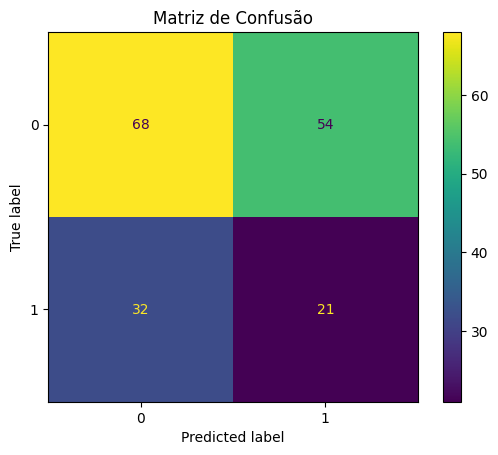

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de Confusão")
plt.show()

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.56      0.61       122
           1       0.28      0.40      0.33        53

    accuracy                           0.51       175
   macro avg       0.48      0.48      0.47       175
weighted avg       0.56      0.51      0.53       175



#Log-Odds e Coeficientes

In [ ]:
coeficientes = pd.DataFrame({
    'Variavel': X.columns,
    'Log_Odds': model.coef_[0]
})

coeficientes = coeficientes.sort_values(by='Log_Odds', ascending=False)

print("\nCoeficientes (Log-Odds):")
print(coeficientes)


Coeficientes (Log-Odds):
                    Variavel  Log_Odds
4     historico_credito_ruim  0.099126
2             sexo_Masculino  0.068996
3  historico_credito_regular -0.002246
0               renda_mensal -0.314565
1                      idade -0.343017


In [ ]:
coeficientes['Odds_Ratio'] = np.exp(coeficientes['Log_Odds'])

print("\nOdds Ratio:")
print(coeficientes)


Odds Ratio:
                    Variavel  Log_Odds  Odds_Ratio
4     historico_credito_ruim  0.099126    1.104206
2             sexo_Masculino  0.068996    1.071432
3  historico_credito_regular -0.002246    0.997756
0               renda_mensal -0.314565    0.730106
1                      idade -0.343017    0.709626


#Insight

A previsão do modelo mostra que é possível identificar previamente clientes com maior risco de inadimplência, permitindo decisões de crédito mais seguras e estratégicas. Ao atribuir probabilidades, o modelo ajuda a reduzir perdas financeiras, melhorar a aprovação de bons clientes e evitar concessões arriscadas, aumentando a eficiência e a lucratividade da operação.